<center><h1>Soundalgekar_Abhishek_HW5</h1></center>
<br>
<br>

Name: Abhishek Soundalgekar
<br>
Github Username: ABHISHEKSOUNDALGEKAR
<br>
USC ID: 2089011000

## 1. Decision Trees as Interpretable clfs

#### Import packages

In [1]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, GridSearchCV, KFold, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import (LinearRegression,Ridge, RidgeCV,Lasso, LassoCV)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
# Gradient boosting
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, accuracy_score
warnings.filterwarnings("ignore")

### 1. (a) Obtain Data

#### Download the Accute Inflamations data from - https://archive.ics.uci.edu/ml/datasets/Acute+Inflammations


In [3]:
column_names = ["temperature", "nausea", "lumbar_pain", "urine_pushing", "micturition_pain", "burning_urethra", "inflammation", "nephritis"]
class_names = ["No Inflammation, No Nephritis","Yes Inflammation, No Nephritis","No Inflammation, Yes Nephritis","Yes Inflammation, Yes Nephritis"]

df = pd.read_csv(
    "../data/diagnosis.data",
    header=None,
    names=column_names,
    sep="\t",
    encoding="utf-16"
)

#temperature from "37,5" to float
df["temperature"] = (
    df["temperature"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

#yes/no to boolean for all other columns
for col in column_names[1:]:
    df[col] = df[col].astype(str).str.lower().map({"yes": True, "no": False})

# 4-class integer label: 0=(F,F),1=(T,F),2=(F,T),3=(T,T)
df["Class"] = (
    df["nephritis"].astype(int) * 2 +
    df["inflammation"].astype(int)
)

print("Shape:", df.shape)
print("\nFeatures:", column_names[:-2])
print("\nClass labels:", class_names)
print("\nDistribution:")
print(
    df["Class"]
    .value_counts()
    .sort_index()
    .rename(index=dict(enumerate(class_names)))
)
print("\nSample rows:")
print(df.head())
print("\nDataFrame info:")
df.info()

Shape: (120, 9)

Features: ['temperature', 'nausea', 'lumbar_pain', 'urine_pushing', 'micturition_pain', 'burning_urethra']

Class labels: ['No Inflammation, No Nephritis', 'Yes Inflammation, No Nephritis', 'No Inflammation, Yes Nephritis', 'Yes Inflammation, Yes Nephritis']

Distribution:
Class
No Inflammation, No Nephritis      30
Yes Inflammation, No Nephritis     40
No Inflammation, Yes Nephritis     31
Yes Inflammation, Yes Nephritis    19
Name: count, dtype: int64

Sample rows:
   temperature  nausea  lumbar_pain  urine_pushing  micturition_pain  \
0         35.5   False         True          False             False   
1         35.9   False        False           True              True   
2         35.9   False         True          False             False   
3         36.0   False        False           True              True   
4         36.0   False         True          False             False   

   burning_urethra  inflammation  nephritis  Class  
0            False       

### 1.(b) Build a decision tree on the whole data set and plot it


Diagnosis mapping (first 5):
  diag_tuple  diag_code
0     (0, 0)          0
1     (1, 0)          2
2     (0, 0)          0
3     (1, 0)          2
4     (0, 0)          0

Diagnosis mapping (last 5):
    diag_tuple  diag_code
115     (0, 1)          1
116     (0, 0)          0
117     (0, 1)          1
118     (0, 1)          1
119     (0, 1)          1


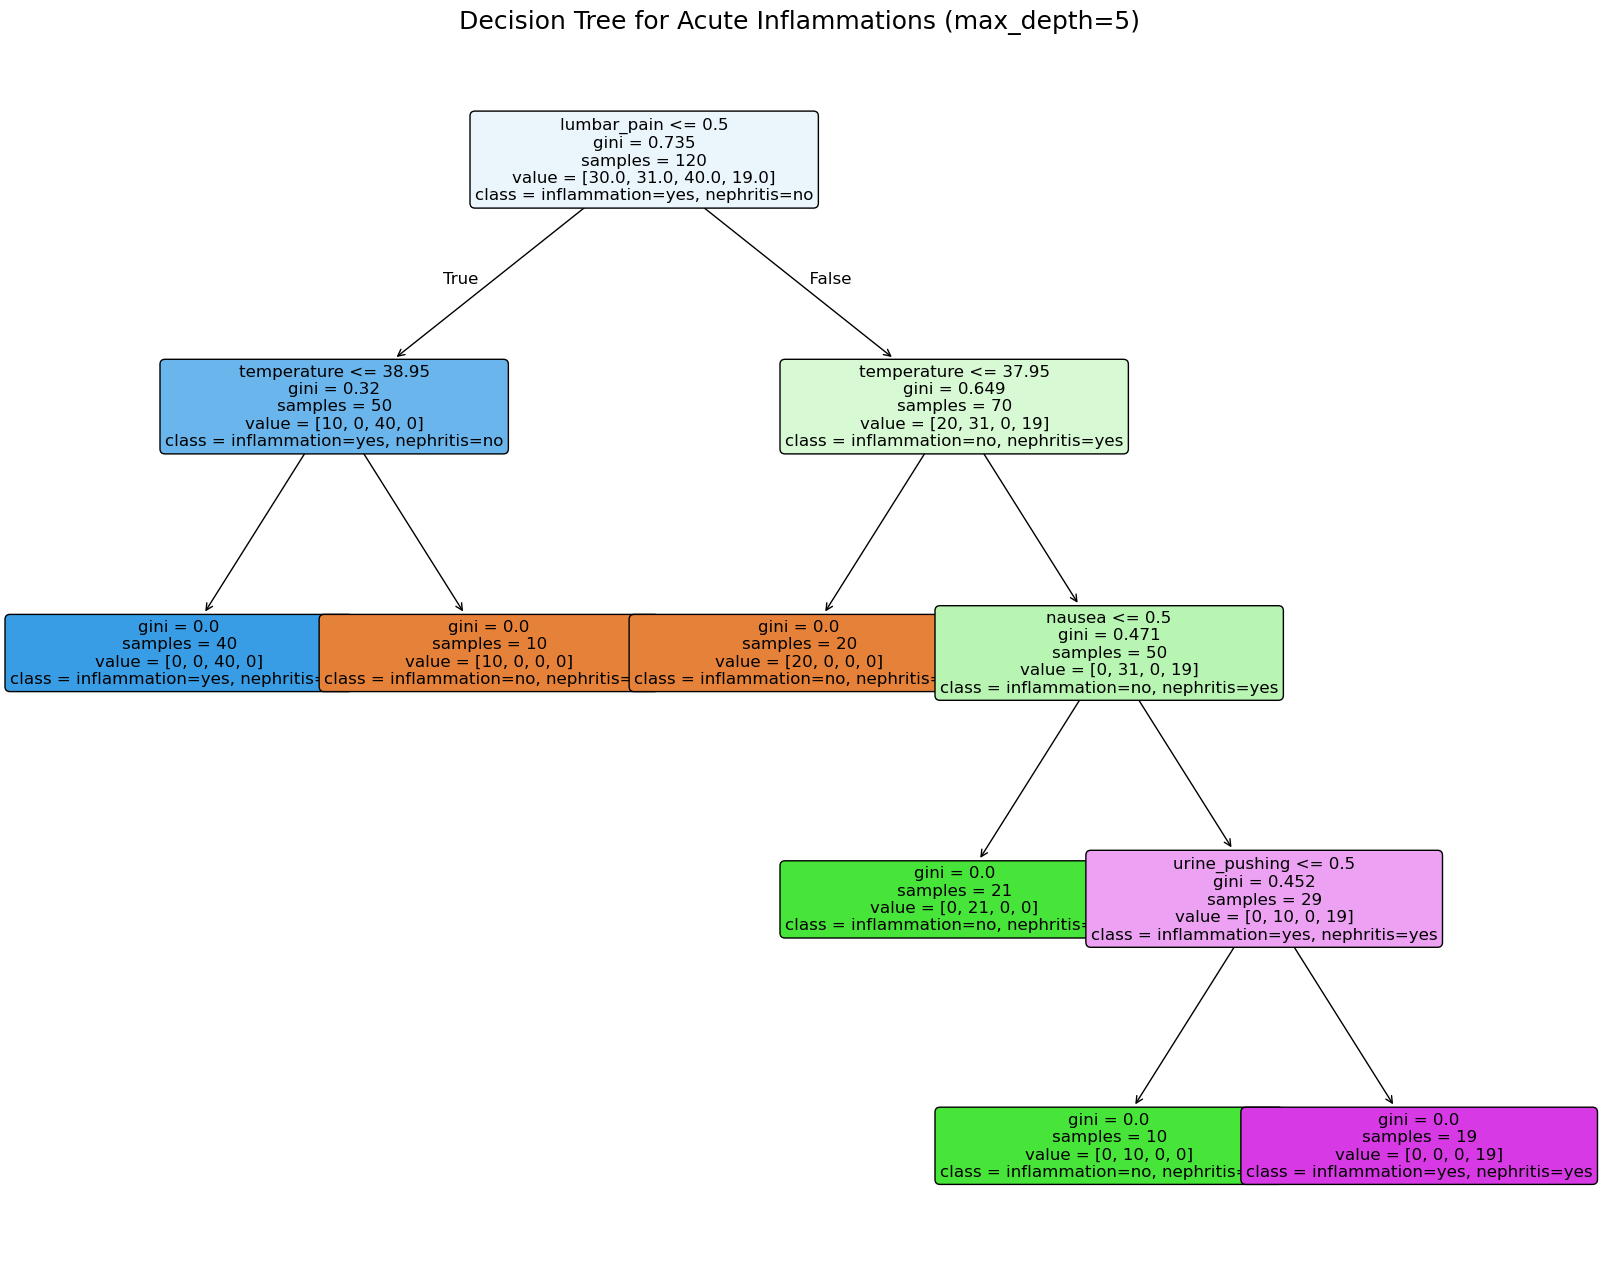

In [4]:
df['diag_tuple'] = list(zip(df['inflammation'].astype(int), df['nephritis'].astype(int)))
unique_tuples = sorted(set(df['diag_tuple']))
tuple_to_code = {tpl: idx for idx, tpl in enumerate(unique_tuples)}
df['diag_code'] = df['diag_tuple'].map(tuple_to_code)

#first/last mappings
print("\nDiagnosis mapping (first 5):")
print(df[['diag_tuple','diag_code']].head())
print("\nDiagnosis mapping (last 5):")
print(df[['diag_tuple','diag_code']].tail())

#decision tree with controlled complexity
features = [
    'temperature', 'nausea', 'lumbar_pain',
    'urine_pushing', 'micturition_pain', 'burning_urethra'
]
clf = DecisionTreeClassifier(
    criterion='gini',         #Gini impurity
    max_depth=5,              #limit depth
    min_samples_leaf=8,       #avoid overfitting
    random_state=25
)
clf.fit(df[features], df['diag_code'])

#human‐readable names
code_to_desc = {
    code: f"inflammation={'yes' if tpl[0] else 'no'}, nephritis={'yes' if tpl[1] else 'no'}"
    for tpl, code in tuple_to_code.items()
}

plt.figure(figsize=(20, 16))
plot_tree(
    clf,
    feature_names=features,
    class_names=[code_to_desc[i] for i in sorted(code_to_desc)],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree for Acute Inflammations (max_depth=5)", fontsize=18)
plt.show()


### 1. (c) Convert the decision rules into a set of IF-THEN rules.

In [5]:
features = [
    "temperature", "nausea", "lumbar_pain",
    "urine_pushing", "micturition_pain", "burning_urethra"
]
#raw tree in text form
raw = export_text(clf, feature_names=features)
print("Raw tree structure:\n", raw)

#Extract IF–THEN rules
def extract_rules(tree, features, labels):
    t = tree.tree_
    lefts, rights = t.children_left, t.children_right
    feats, thresh, vals = t.feature, t.threshold, t.value

    rules = []
    def walk(node, conds):
        if lefts[node] != rights[node]:
            name = features[feats[node]]
            th = thresh[node]
            walk(lefts[node], conds + [f"{name} ≤ {th:.3f}"])
            walk(rights[node], conds + [f"{name} > {th:.3f}"])
        else:
            cls = vals[node][0].argmax()
            rules.append((conds, labels[cls]))
    walk(0, [])
    return rules

rules = extract_rules(clf, features, class_names)

print("\nExtracted IF–THEN Rules:\n")
for idx, (conds, outcome) in enumerate(rules, 1):
    print(f"Rule {idx}:")
    print("  IF " + " AND ".join(conds))
    print(f"  THEN → {outcome}\n")


Raw tree structure:
 |--- lumbar_pain <= 0.50
|   |--- temperature <= 38.95
|   |   |--- class: 2
|   |--- temperature >  38.95
|   |   |--- class: 0
|--- lumbar_pain >  0.50
|   |--- temperature <= 37.95
|   |   |--- class: 0
|   |--- temperature >  37.95
|   |   |--- nausea <= 0.50
|   |   |   |--- class: 1
|   |   |--- nausea >  0.50
|   |   |   |--- urine_pushing <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- urine_pushing >  0.50
|   |   |   |   |--- class: 3


Extracted IF–THEN Rules:

Rule 1:
  IF lumbar_pain ≤ 0.500 AND temperature ≤ 38.950
  THEN → No Inflammation, Yes Nephritis

Rule 2:
  IF lumbar_pain ≤ 0.500 AND temperature > 38.950
  THEN → No Inflammation, No Nephritis

Rule 3:
  IF lumbar_pain > 0.500 AND temperature ≤ 37.950
  THEN → No Inflammation, No Nephritis

Rule 4:
  IF lumbar_pain > 0.500 AND temperature > 37.950 AND nausea ≤ 0.500
  THEN → Yes Inflammation, No Nephritis

Rule 5:
  IF lumbar_pain > 0.500 AND temperature > 37.950 AND nausea > 0.500 AND u

### 1. (d)Use cost-complexity pruning to find a minimal decision tree and a set of decision rules with high interpretability.

Optimal ccp_alpha: 0.0982
Cross‐val accuracy: 0.7750


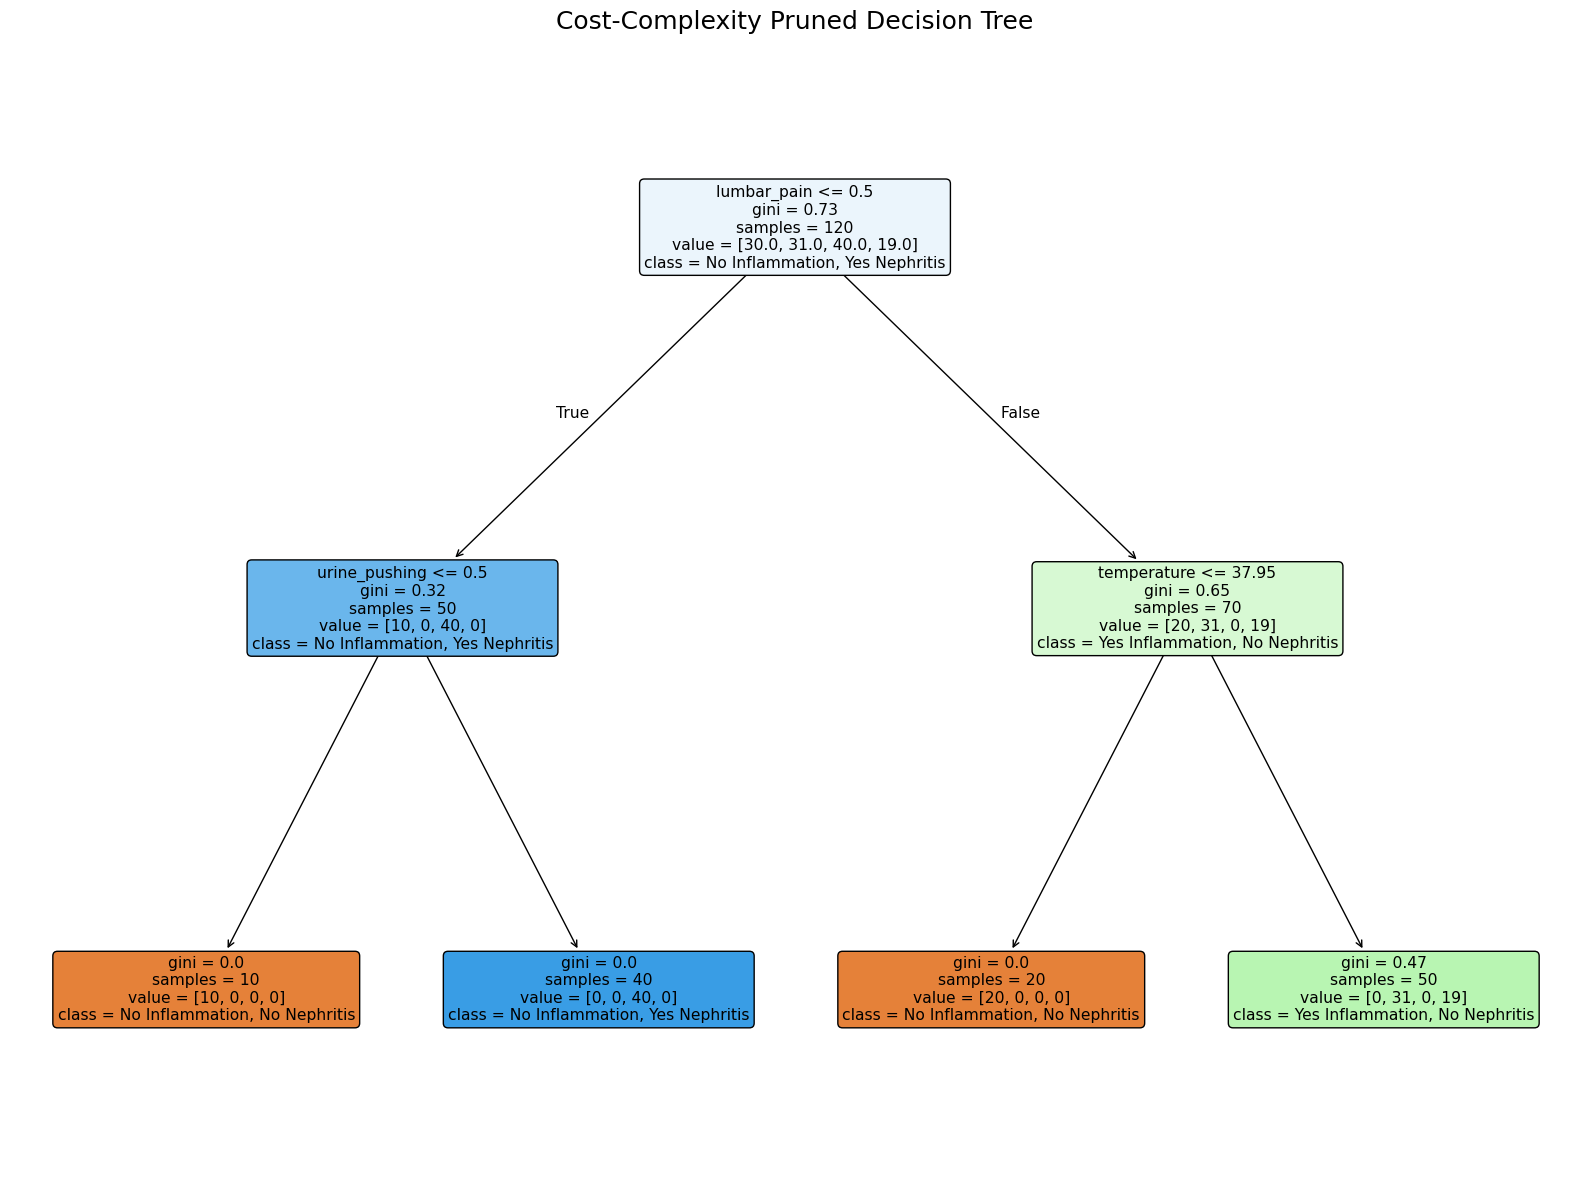

In [6]:
#pruning path for the original tree `clf`
prune_data = clf.cost_complexity_pruning_path(df[features], df['diag_code'])
ccp_alphas = np.unique(prune_data.ccp_alphas)
ccp_alphas = ccp_alphas[ccp_alphas > 0]  # drop alpha=0

#Grid‐search to find optimal ccp_alpha
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={'ccp_alpha': ccp_alphas},
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
grid.fit(df[features], df['diag_code'])

#best pruned tree and its performance
pruned_tree = grid.best_estimator_
print(f"Optimal ccp_alpha: {grid.best_params_['ccp_alpha']:.4f}")
print(f"Cross‐val accuracy: {grid.best_score_:.4f}")

plt.figure(figsize=(16, 12))
plot_tree(
    pruned_tree,
    feature_names=features,
    class_names=class_names,
    filled=True,
    rounded=True,
    precision=2
)
plt.title("Cost‐Complexity Pruned Decision Tree", fontsize=18)
plt.tight_layout()
plt.show()

Optimal ccp_alpha: 0.0982
<br>
Cross‐val accuracy: 0.7750

In [7]:
#IF–THEN rules from the pruned tree
pruned_rules = extract_rules(pruned_tree, features, class_names)

print("IF THEN Decision rules for the PRUNED Decision Tree (Cost-complexity pruning):\n")
for idx, rule in enumerate(pruned_rules, 1):
    print(f"Rule {idx}:")
    for line in rule:
        print(line)
    print("." * 75)

IF THEN Decision rules for the PRUNED Decision Tree (Cost-complexity pruning):

Rule 1:
['lumbar_pain ≤ 0.500', 'urine_pushing ≤ 0.500']
No Inflammation, No Nephritis
...........................................................................
Rule 2:
['lumbar_pain ≤ 0.500', 'urine_pushing > 0.500']
No Inflammation, Yes Nephritis
...........................................................................
Rule 3:
['lumbar_pain > 0.500', 'temperature ≤ 37.950']
No Inflammation, No Nephritis
...........................................................................
Rule 4:
['lumbar_pain > 0.500', 'temperature > 37.950']
Yes Inflammation, No Nephritis
...........................................................................


- - -

### 2. The LASSO and Boosting for Regression

### 2.(a) Download the Communities and Crime data3 from https://archive.ics.uci.edu/ml/datasets/Communities+and+Crime. Use the first 1495 rows of data as the training set and the rest as the test set.

In [8]:
df2 = pd.read_csv("../data/communities.data", header=None, na_values="?", sep=",", comment="#")
print(df2.head()) 

   0     1        2                    3    4     5     6     7     8     9    \
0    8   NaN      NaN         Lakewoodcity    1  0.19  0.33  0.02  0.90  0.12   
1   53   NaN      NaN          Tukwilacity    1  0.00  0.16  0.12  0.74  0.45   
2   24   NaN      NaN         Aberdeentown    1  0.00  0.42  0.49  0.56  0.17   
3   34   5.0  81440.0  Willingborotownship    1  0.04  0.77  1.00  0.08  0.12   
4   42  95.0   6096.0    Bethlehemtownship    1  0.01  0.55  0.02  0.95  0.09   

   ...   118   119   120   121   122  123  124   125   126   127  
0  ...  0.12  0.26  0.20  0.06  0.04  0.9  0.5  0.32  0.14  0.20  
1  ...  0.02  0.12  0.45   NaN   NaN  NaN  NaN  0.00   NaN  0.67  
2  ...  0.01  0.21  0.02   NaN   NaN  NaN  NaN  0.00   NaN  0.43  
3  ...  0.02  0.39  0.28   NaN   NaN  NaN  NaN  0.00   NaN  0.12  
4  ...  0.04  0.09  0.02   NaN   NaN  NaN  NaN  0.00   NaN  0.03  

[5 rows x 128 columns]


In [9]:
#training and test sets based on the first 1,495 rows
train_df = df2.iloc[:1495].reset_index(drop=True)
test_df  = df2.iloc[1495:].reset_index(drop=True)

#shapes for both sets
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape:     {test_df.shape}")
display(train_df)
display(test_df)

Training set shape: (1495, 128)
Test set shape:     (499, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.90,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,6,NaN,NaN,Hillsboroughtown,8,0.00,0.59,0.01,0.69,1.00,...,0.02,0.14,0.22,NaN,NaN,NaN,NaN,0.00,NaN,0.03
1491,6,NaN,NaN,Orangecity,8,0.16,0.62,0.03,0.74,0.48,...,0.07,0.40,0.14,0.07,0.05,0.85,0.5,0.61,0.19,0.20
1492,13,NaN,NaN,Waycrosscity,8,0.01,0.36,0.95,0.24,0.03,...,0.03,0.12,0.01,NaN,NaN,NaN,NaN,0.00,NaN,0.30
1493,39,85.0,49056.0,Mentorcity,8,0.06,0.53,0.01,0.98,0.05,...,0.08,0.15,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,6,NaN,NaN,MillValleycity,8,0.00,0.20,0.03,0.91,0.23,...,0.01,0.23,0.73,NaN,NaN,NaN,NaN,0.00,NaN,0.12
1,48,NaN,NaN,LiveOakcity,8,0.00,0.55,0.13,0.78,0.15,...,0.01,0.18,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.11
2,35,NaN,NaN,Portalescity,8,0.00,0.52,0.04,0.59,0.05,...,0.01,0.18,0.00,NaN,NaN,NaN,NaN,0.00,NaN,0.12
3,42,17.0,25112.0,Fallstownship,8,0.04,0.51,0.07,0.92,0.09,...,0.06,0.13,0.16,NaN,NaN,NaN,NaN,0.00,NaN,0.06
4,51,683.0,48952.0,Manassascity,8,0.03,0.59,0.20,0.75,0.19,...,0.03,0.23,0.06,NaN,NaN,NaN,NaN,0.00,NaN,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,12,NaN,NaN,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,NaN,NaN,NaN,NaN,0.00,NaN,0.09
495,6,NaN,NaN,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,NaN,NaN,NaN,NaN,0.00,NaN,0.45
496,9,9.0,80070.0,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0.0,0.91,0.28,0.23
497,25,17.0,72600.0,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0.0,0.22,0.18,0.19


### 2.(b) The data set has missing values. Use a data imputation technique to deal with the missing values in the data set. The data description mentions some features are nonpredictive. Ignore those features.

In [10]:
#drop by position using iloc
train_df = train_df.iloc[:, 5:].reset_index(drop=True)
test_df  = test_df.iloc[:, 5:].reset_index(drop=True)

#drop by grabbing the first 5 column names
cols_to_drop = train_df.columns[:5]
train_df = train_df.drop(columns=cols_to_drop).reset_index(drop=True)
test_df  = test_df.drop(columns=cols_to_drop).reset_index(drop=True)

#impute:
imputer = SimpleImputer(strategy="median")
train_imputed = pd.DataFrame(
    imputer.fit_transform(train_df),
    columns=train_df.columns
)
test_imputed = pd.DataFrame(
    imputer.transform(test_df),
    columns=test_df.columns
)

print(f"Training set after drop & impute: {train_imputed.shape}")
display(train_imputed.head())

print(f"Test set after drop & impute:     {test_imputed.shape}")
display(test_imputed.head())


Training set after drop & impute: (1495, 118)


,10,11,12,13,14,15,16,17,18,19,...,118,119,120,121,122,123,124,125,126,127
0,0.17,0.34,0.47,0.29,0.32,0.20,1.0,0.37,0.72,0.34,...,0.12,0.26,0.20,0.06,0.04,0.90,0.5,0.32,0.14,0.20
1,0.07,0.26,0.59,0.35,0.27,0.02,1.0,0.31,0.72,0.11,...,0.02,0.12,0.45,0.07,0.03,0.76,0.5,0.00,0.15,0.67
2,0.04,0.39,0.47,0.28,0.32,0.00,0.0,0.30,0.58,0.19,...,0.01,0.21,0.02,0.07,0.03,0.76,0.5,0.00,0.15,0.43
3,0.10,0.51,0.50,0.34,0.21,0.06,1.0,0.58,0.89,0.21,...,0.02,0.39,0.28,0.07,0.03,0.76,0.5,0.00,0.15,0.12
4,0.05,0.38,0.38,0.23,0.36,0.02,0.9,0.50,0.72,0.16,...,0.04,0.09,0.02,0.07,0.03,0.76,0.5,0.00,0.15,0.03


Test set after drop & impute:     (499, 118)


,10,11,12,13,14,15,16,17,18,19,...,118,119,120,121,122,123,124,125,126,127
0,0.05,0.15,0.19,0.09,0.42,0.02,1.0,0.73,0.48,0.31,...,0.01,0.23,0.73,0.07,0.03,0.76,0.5,0.0,0.15,0.12
1,0.36,0.48,0.53,0.30,0.10,0.02,1.0,0.40,0.87,0.37,...,0.01,0.18,0.02,0.07,0.03,0.76,0.5,0.0,0.15,0.11
2,0.62,0.84,0.78,0.75,0.43,0.00,0.0,0.08,0.42,0.78,...,0.01,0.18,0.00,0.07,0.03,0.76,0.5,0.0,0.15,0.12
3,0.03,0.38,0.47,0.27,0.35,0.06,1.0,0.47,0.72,0.14,...,0.06,0.13,0.16,0.07,0.03,0.76,0.5,0.0,0.15,0.06
4,0.10,0.38,0.62,0.35,0.11,0.04,1.0,0.58,0.91,0.16,...,0.03,0.23,0.06,0.07,0.03,0.76,0.5,0.0,0.15,0.12


In [11]:
#target column (assumed to be the last one)
target_col = train_df.columns[-1]

#features (X) and target (y)
X_train, y_train = train_df.drop(columns=target_col), train_df[target_col]
X_test,  y_test  = test_df.drop(columns=target_col),  test_df[target_col]

#median imputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

#imputed features with the target
imputed_train_df = pd.concat([X_train_imputed, y_train], axis=1)
imputed_test_df  = pd.concat([X_test_imputed,  y_test],  axis=1)

#shapes
print(f"Imputed training set shape: {imputed_train_df.shape}")
display(imputed_train_df.head())

print(f"Imputed test set shape:     {imputed_test_df.shape}")
display(imputed_test_df.head())


Imputed training set shape: (1495, 118)


,10,11,12,13,14,15,16,17,18,19,...,118,119,120,121,122,123,124,125,126,127
0,0.17,0.34,0.47,0.29,0.32,0.20,1.0,0.37,0.72,0.34,...,0.12,0.26,0.20,0.06,0.04,0.90,0.5,0.32,0.14,0.20
1,0.07,0.26,0.59,0.35,0.27,0.02,1.0,0.31,0.72,0.11,...,0.02,0.12,0.45,0.07,0.03,0.76,0.5,0.00,0.15,0.67
2,0.04,0.39,0.47,0.28,0.32,0.00,0.0,0.30,0.58,0.19,...,0.01,0.21,0.02,0.07,0.03,0.76,0.5,0.00,0.15,0.43
3,0.10,0.51,0.50,0.34,0.21,0.06,1.0,0.58,0.89,0.21,...,0.02,0.39,0.28,0.07,0.03,0.76,0.5,0.00,0.15,0.12
4,0.05,0.38,0.38,0.23,0.36,0.02,0.9,0.50,0.72,0.16,...,0.04,0.09,0.02,0.07,0.03,0.76,0.5,0.00,0.15,0.03


Imputed test set shape:     (499, 118)


,10,11,12,13,14,15,16,17,18,19,...,118,119,120,121,122,123,124,125,126,127
0,0.05,0.15,0.19,0.09,0.42,0.02,1.0,0.73,0.48,0.31,...,0.01,0.23,0.73,0.07,0.03,0.76,0.5,0.0,0.15,0.12
1,0.36,0.48,0.53,0.30,0.10,0.02,1.0,0.40,0.87,0.37,...,0.01,0.18,0.02,0.07,0.03,0.76,0.5,0.0,0.15,0.11
2,0.62,0.84,0.78,0.75,0.43,0.00,0.0,0.08,0.42,0.78,...,0.01,0.18,0.00,0.07,0.03,0.76,0.5,0.0,0.15,0.12
3,0.03,0.38,0.47,0.27,0.35,0.06,1.0,0.47,0.72,0.14,...,0.06,0.13,0.16,0.07,0.03,0.76,0.5,0.0,0.15,0.06
4,0.10,0.38,0.62,0.35,0.11,0.04,1.0,0.58,0.91,0.16,...,0.03,0.23,0.06,0.07,0.03,0.76,0.5,0.0,0.15,0.12


### 2. (c) Plot a correlation matrix for the features in the data set.

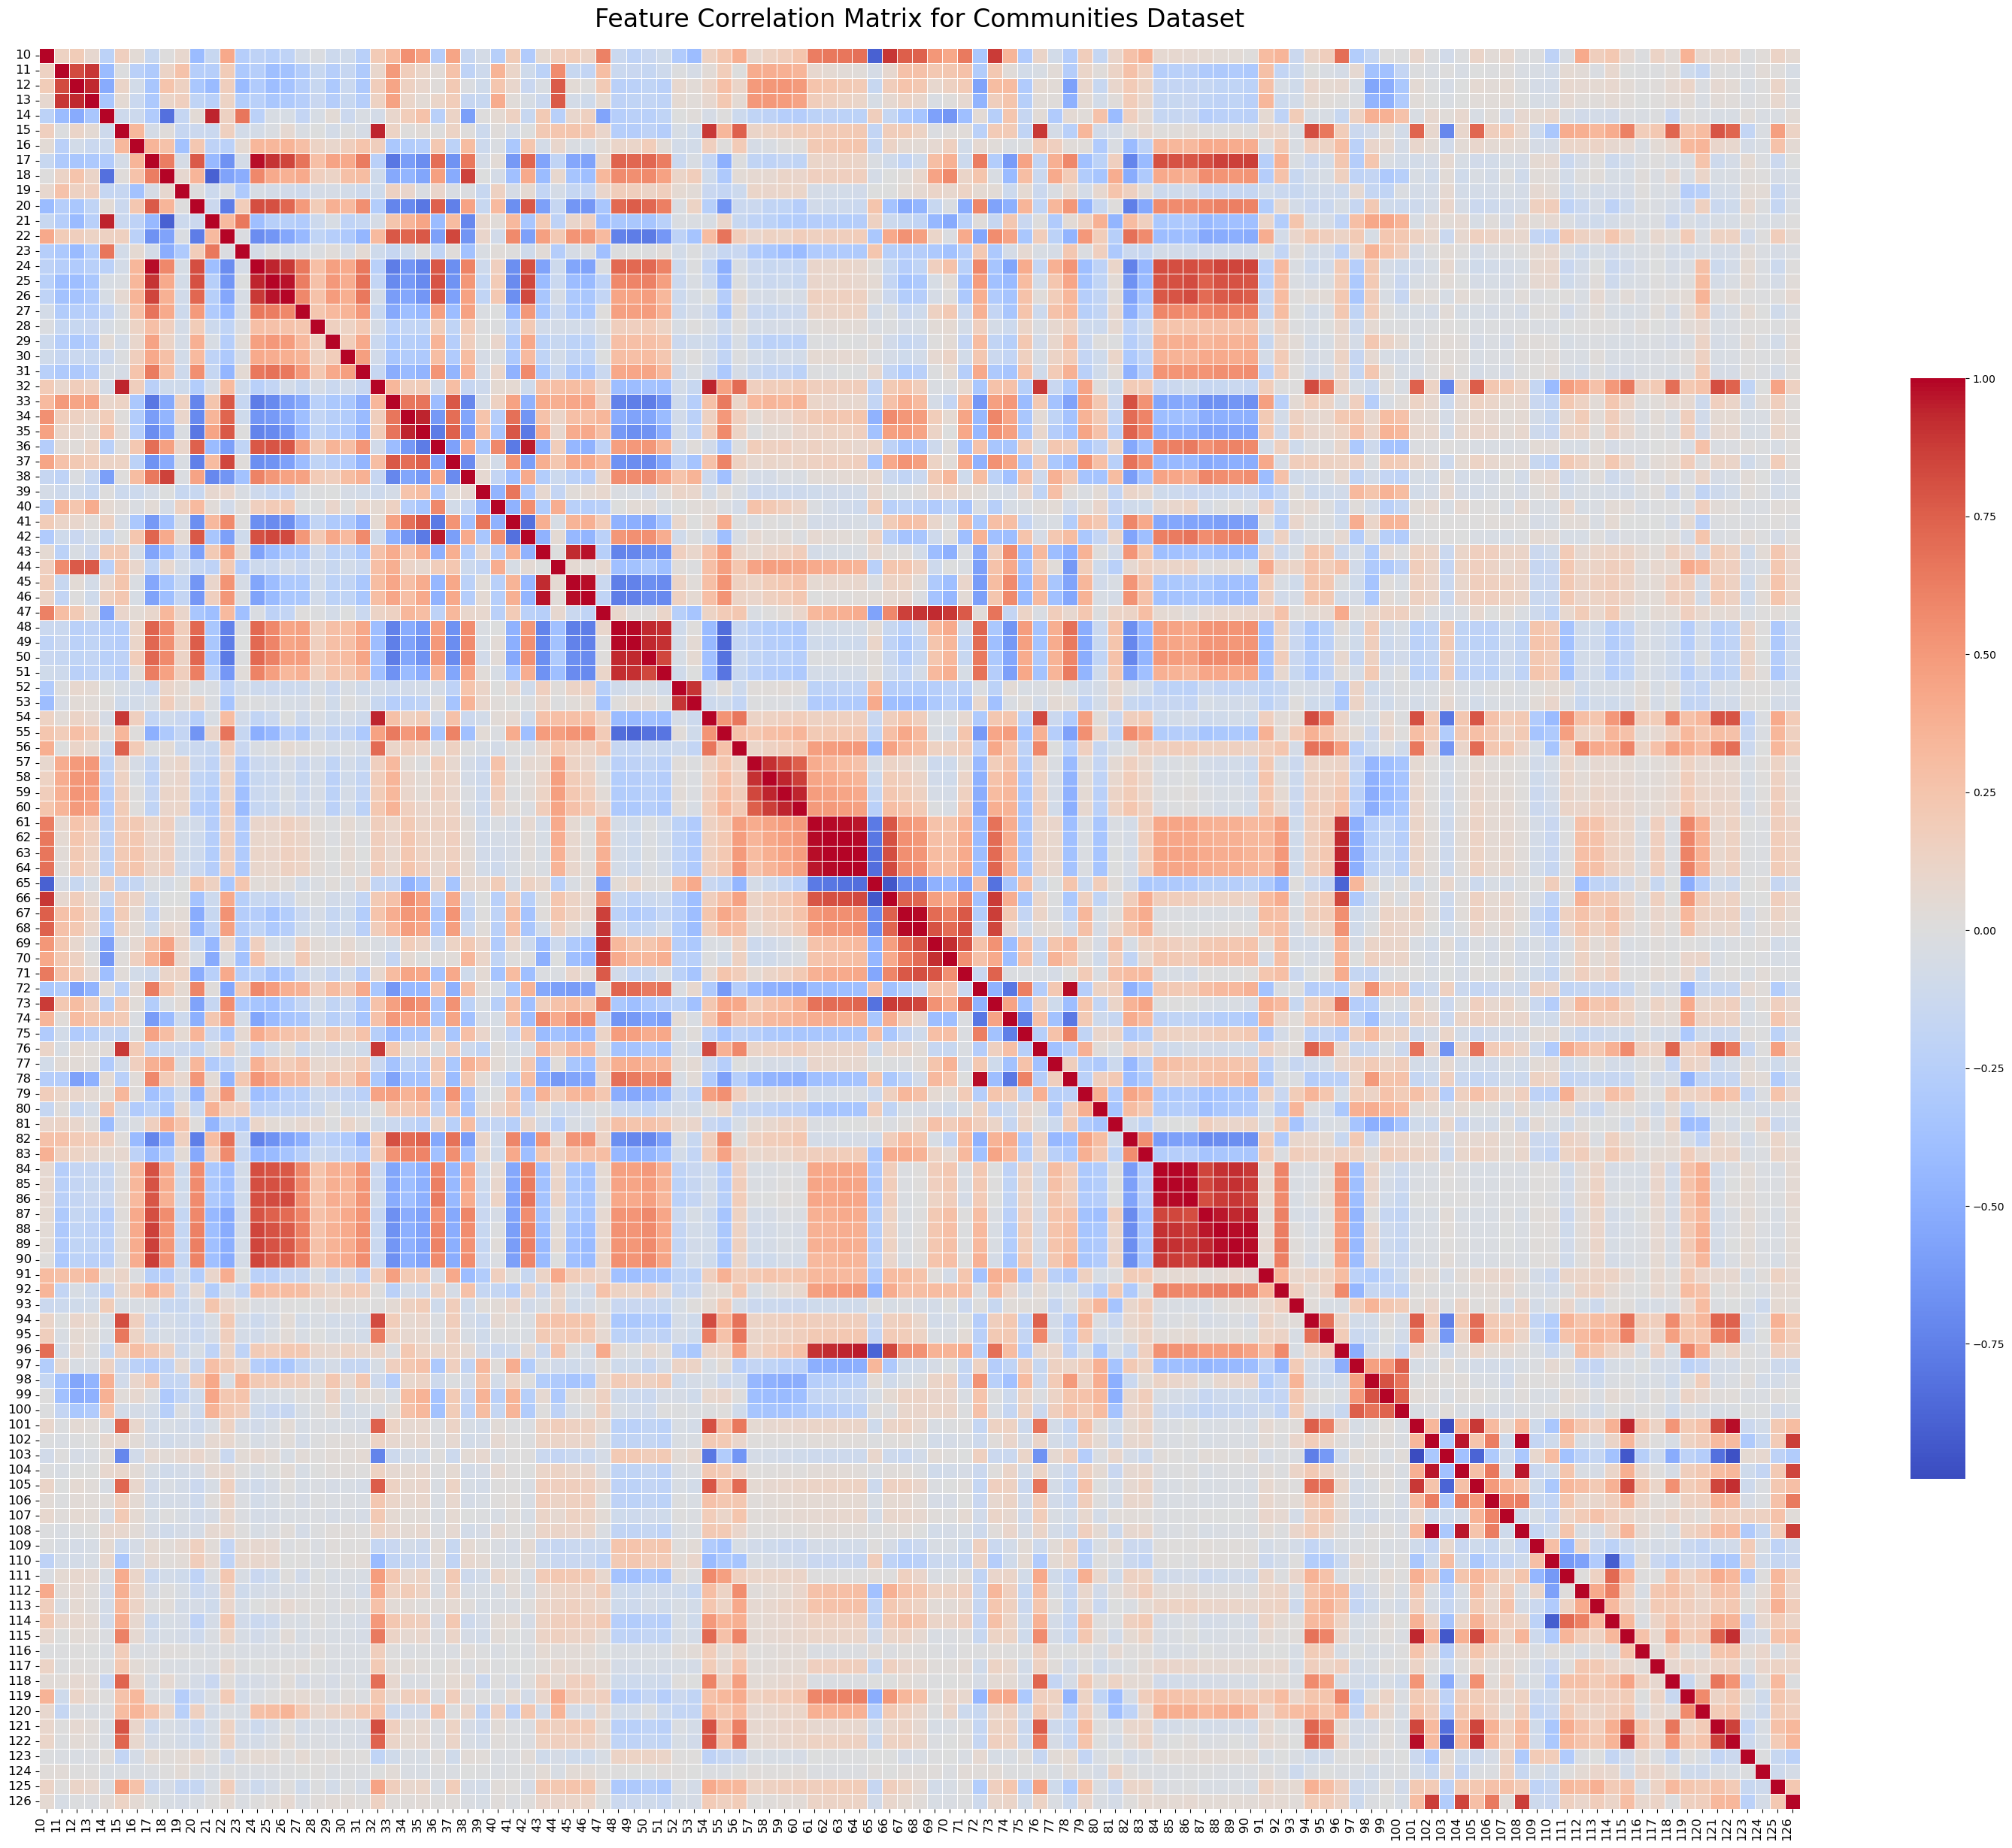

In [12]:
train_features = imputed_train_df.iloc[:, :-1]
corr = train_features.corr()

plt.figure(figsize=(30, 25), dpi=100)

sns.heatmap(
    corr,
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.6},
    xticklabels=True,
    yticklabels=True
)

plt.title("Feature Correlation Matrix for Communities Dataset", fontsize=24, pad=20)
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()



### 2. (d) Calculate the Coefficient of Variation CV

In [13]:
def compute_coefficient_of_variation(
    df: pd.DataFrame,
    ddof: int = 1,
    top_n: int = 10
) -> pd.Series:
    means = df.mean()
    stds = df.std(ddof=ddof)
    # Avoid division by zero by replacing zero means with NaN
    means_safe = means.replace(0, np.nan)
    cv = (stds / means_safe) * 100
    cv_abs = cv.abs().sort_values(ascending=False)
    return cv_abs.head(top_n)

#top 11 features by CV on training features
X_train = imputed_train_df.iloc[:, :-1]  # features only
cv_top10 = compute_coefficient_of_variation(X_train, ddof=1, top_n=11)
print("Top 11 features by coefficient of variation:")
for feature, cv_value in cv_top10.items():
    print(f"{feature}: {cv_value:.2f}%")

#CV across all features directly using std() and mean()
imputed_df = X_train.copy()
std_dev = imputed_df.std(ddof=1)
mean = imputed_df.mean()
cv_full = std_dev / mean
print("\nCoefficient of variation for all features:")
print(cv_full)

Top 11 features by coefficient of variation:
113: 552.71%
95: 429.29%
94: 347.10%
54: 305.90%
56: 292.66%
125: 255.29%
32: 234.24%
101: 224.80%
15: 203.85%
76: 196.85%
122: 164.55%

Coefficient of variation for all features:
10     1.612091
11     0.369083
12     0.291315
13     0.500310
14     0.412776
         ...   
122    1.645508
123    0.112032
124    0.335104
125    2.552946
126    0.408650
Length: 117, dtype: float64


### 2. (e) Pick  √128 features with highest CV , and make scatter plots and box plots for them. Can you draw conclusions about significance of those features, just by the scatter plots?


Top 10 features by Coefficient of Variation:


,CV (%)
113,552.705874
95,429.292299
94,347.095214
54,305.896435
56,292.663525
125,255.294551
32,234.244312
101,224.804157
15,203.846149
76,196.846705



Pairwise relationships among top CV features:


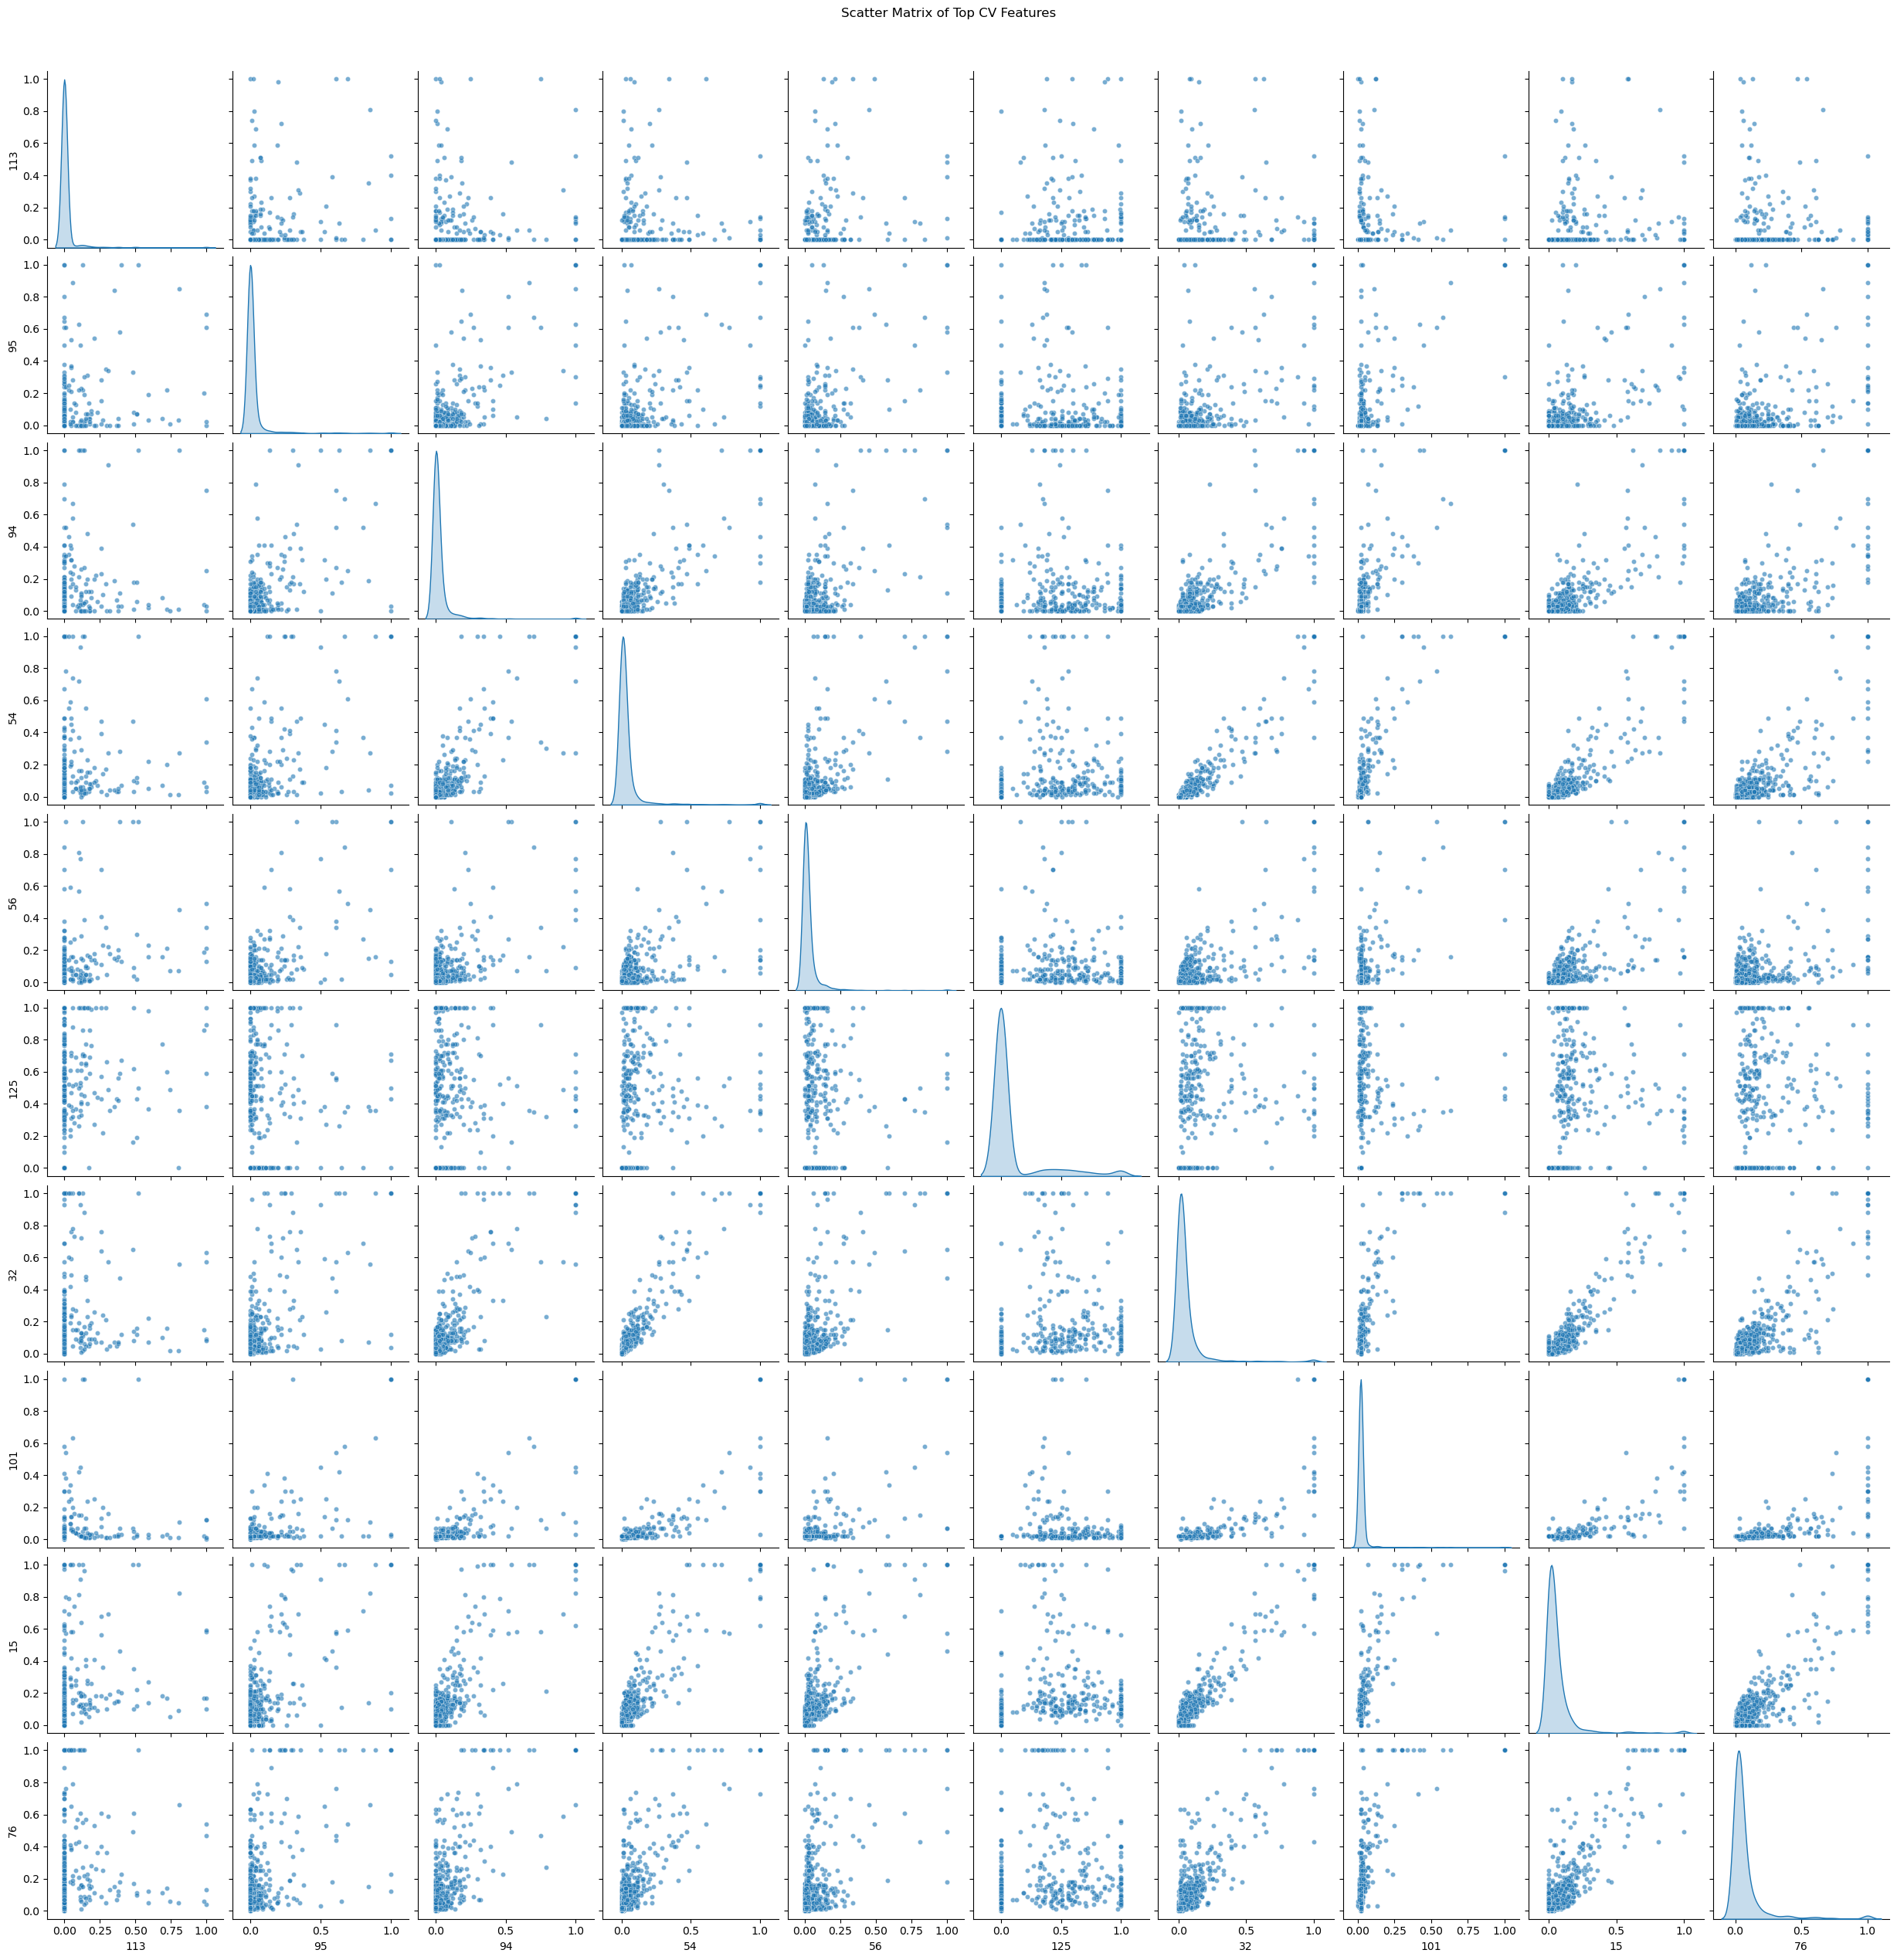


Boxplots of top CV features:


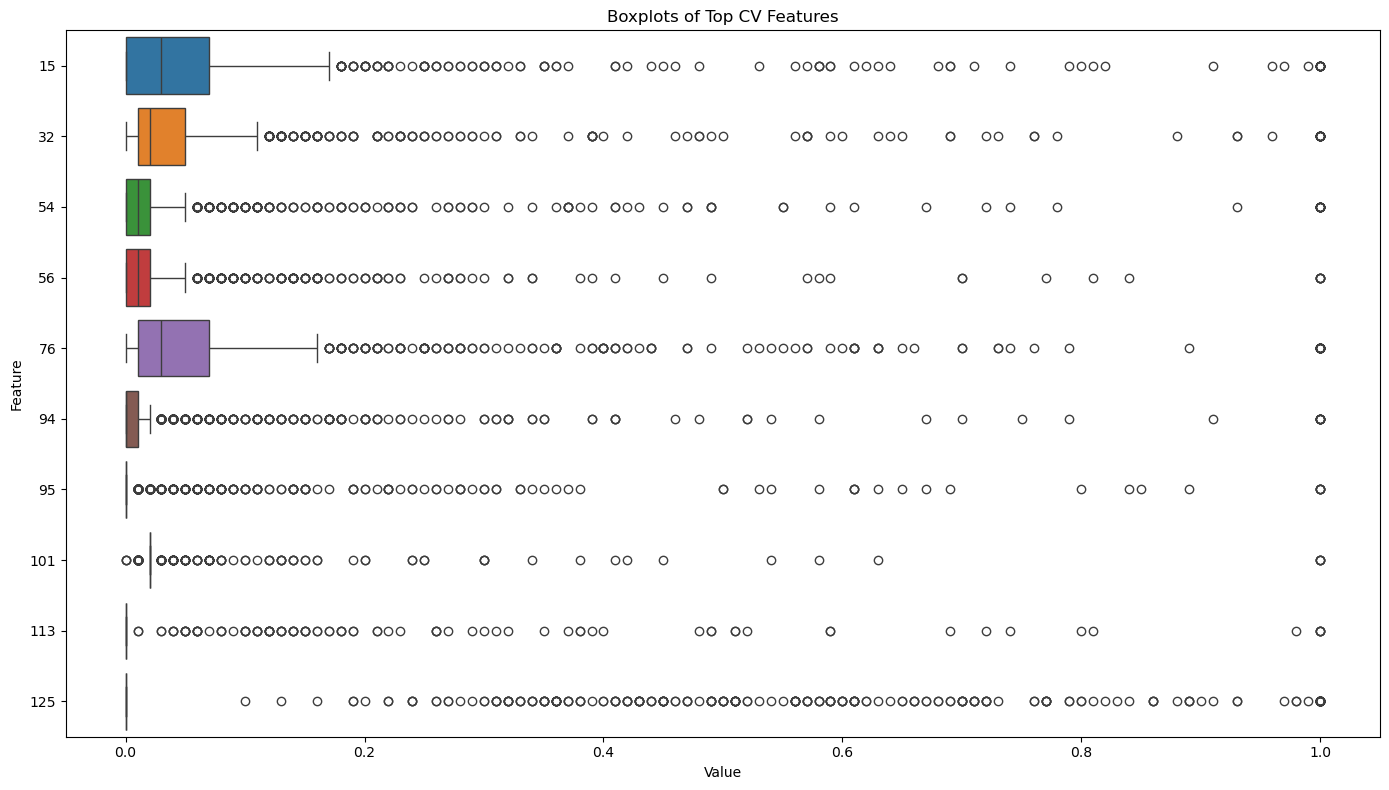


Individual scatter plots:


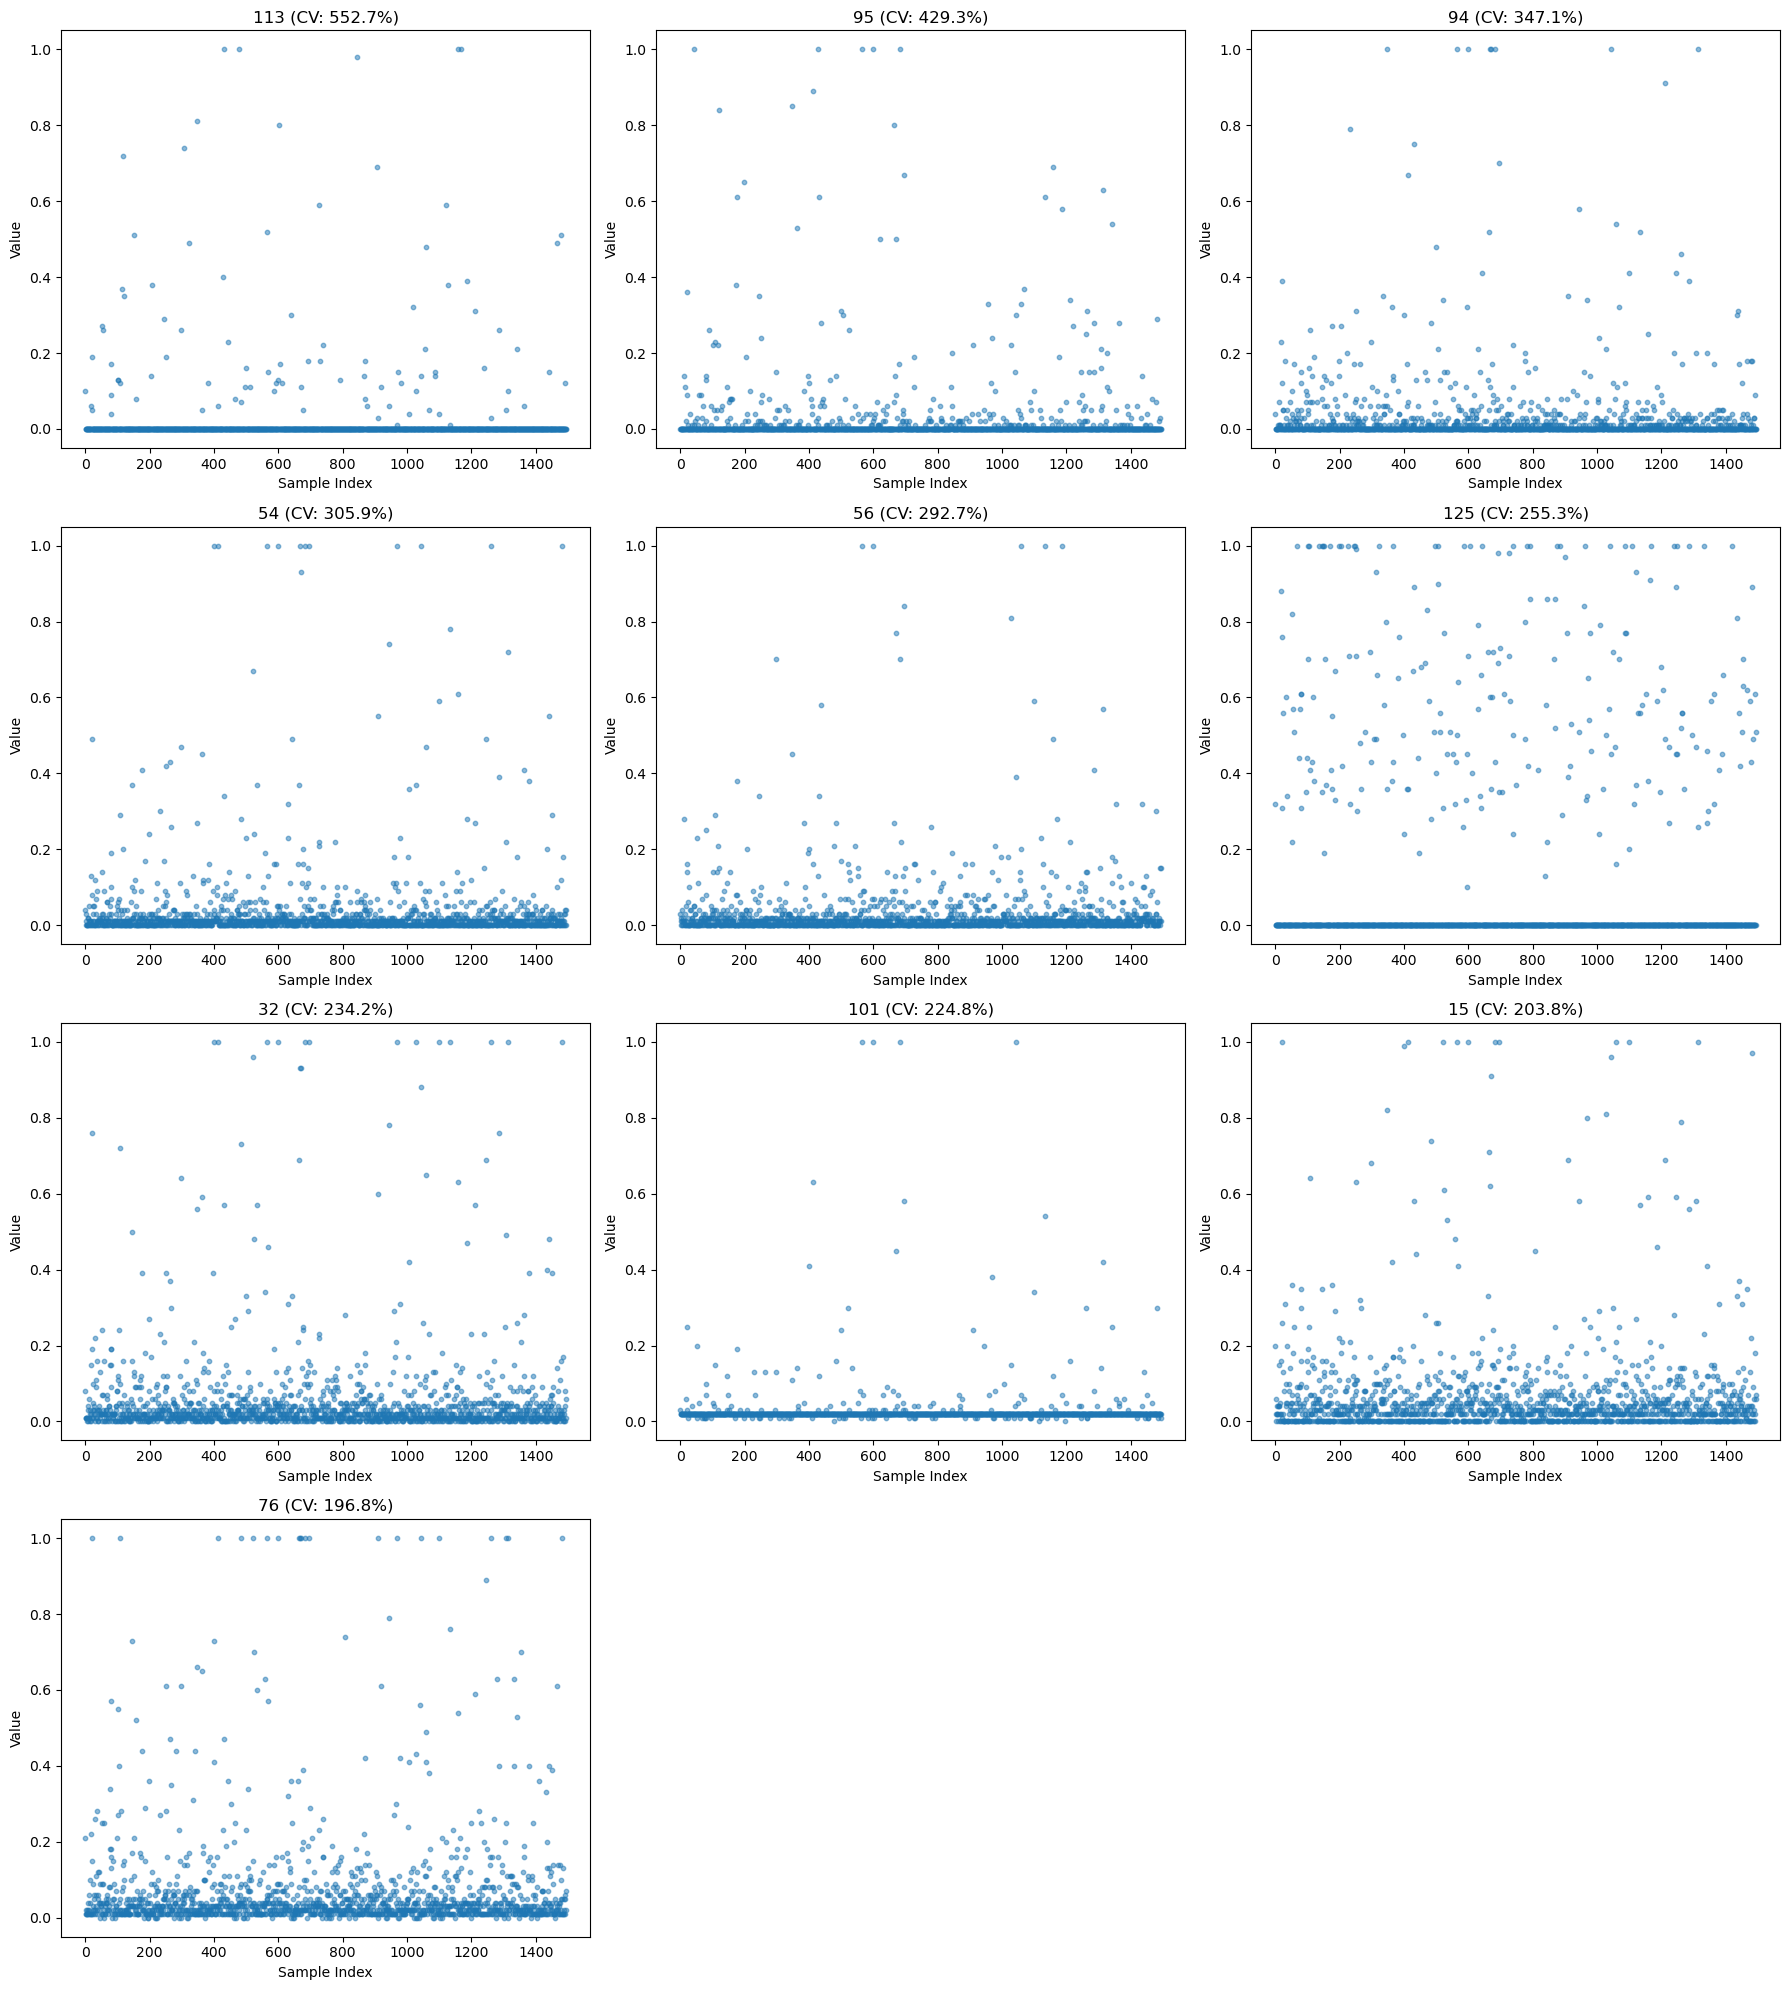

In [14]:
std_dev   = X_train.std(ddof=1)
mean_vals = X_train.mean().replace(0, np.nan)
cv_series = (std_dev / mean_vals).abs() * 100
cv_df     = cv_series.sort_values(ascending=False).rename("CV (%)").to_frame()

#number of features to select
n_features = math.floor(math.sqrt(X_train.shape[1]))

#top features by CV
top_feats = cv_df.head(n_features).index.tolist()

#top CV values as a table
print(f"Top {n_features} features by Coefficient of Variation:")
display(cv_df.head(n_features))

#scatter matrix of top features
print("\nPairwise relationships among top CV features:")
sns.pairplot(X_train[top_feats], diag_kind='kde', plot_kws={'alpha':0.6, 's':20})
plt.suptitle("Scatter Matrix of Top CV Features", y=1.02)
plt.show()

#Boxplots of top features
print("\nBoxplots of top CV features:")
plt.figure(figsize=(14, 8))
sns.boxplot(data=X_train[top_feats], orient='h', whis=1.5)
plt.title("Boxplots of Top CV Features")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#Individual scatter plots over sample index
print("\nIndividual scatter plots:")
fig, axes = plt.subplots(nrows=math.ceil(n_features/3), ncols=3, figsize=(18, 5 * math.ceil(n_features/3)))
axes = axes.flatten()
for ax, feat in zip(axes, top_feats):
    ax.scatter(range(len(X_train)), X_train[feat], alpha=0.5, s=10)
    ax.set_title(f"{feat} (CV: {cv_series[feat]:.1f}%)")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Value")
    
for ax in axes[len(top_feats):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


1. **Preliminary Insight:**
   “The scatter matrix alone does not provide sufficient evidence to draw firm conclusions additional analyses (e.g., statistical tests, domain context, or complementary visualizations) are needed before making reliable inferences.”

2. **Combined Interpretation:**
   “When viewed together, the scatterplots and boxplots reveal that features 90 and 120 have noticeably lower coefficient of variation compared to the others, indicating they may serve as more stable and informative predictors in subsequent modeling.”


### 2.(f) Fit a linear model using least squares to the training set and report the test error.


In [15]:
train = imputed_train_df.reset_index(drop=True)
test  = imputed_test_df.reset_index(drop=True)

feature_cols = train.columns[:-1]
target_col   = train.columns[-1]

X_train = train[feature_cols]
y_train = train[target_col]
X_test  = test [feature_cols]
y_test  = test [target_col] 

#Statsmodels OLS fit & test MSE
X_train_sm = sm.add_constant(X_train)
ols_model  = sm.OLS(y_train, X_train_sm).fit()

#test set
X_test_sm  = sm.add_constant(X_test)
y_pred_sm  = ols_model.predict(X_test_sm)

#MSE
mse_sm = mean_squared_error(y_test, y_pred_sm)
print(f"Statsmodels OLS Test MSE: {mse_sm:.5f}")

#Scikit-learn LinearRegression fit & test MSE
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
mse_lr    = mean_squared_error(y_test, y_pred_lr)
# print(f"Scikit-learn Linear Regression Test MSE: {mse_lr:.5f}")

Statsmodels OLS Test MSE: 0.01768


The test mean squared error for LINEAR model: 0.01754

### 2. (g) Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained.


In [16]:
#geometric sequence of candidate regularization strengths
alphas_to_test = np.geomspace(1e-4, 1e4, num=100)

#Ridge regressor and grid‐search wrapper
ridge_regressor = Ridge()
param_grid = {'alpha': alphas_to_test}

ridge_search = GridSearchCV(
    estimator=ridge_regressor,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,       # use all cores
    verbose=1        # show progress
)

#training data fit
ridge_search.fit(X_train, y_train)

#optimal alpha
best_alpha = ridge_search.best_params_['alpha']
print(f"Optimal alpha for Ridge Regression: {best_alpha:.6f}")

#predictions on test set
y_pred_ridge = ridge_search.predict(X_test)

#test‐set MSE
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge Regression Test MSE: {ridge_mse:.5f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Optimal alpha for Ridge Regression: 1.592283
Ridge Regression Test MSE: 0.01707


Optimal alpha (λ) for Ridge Regression: 2.310130
<br>
Ridge Regression Test MSE: 0.01708

#### 2.(h) Fit a LASSO model on the training set, with λ chosen by cross-validation. Report the test error obtained, along with a list of the variables selected by the model.


In [17]:
#logarithmic grid of candidate λ (alpha) values
alpha_grid = np.logspace(-4, 4, 100)

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso_cv", LassoCV(
        alphas=alpha_grid,
        cv=5,
        max_iter=10000,
        n_jobs=-1,
        verbose=True,
        random_state=42
    ))
])

#training data
lasso_pipeline.fit(X_train, y_train)

#best λ found by cross-validation
best_lambda = lasso_pipeline.named_steps["lasso_cv"].alpha_
print(f"Optimal λ (alpha) selected: {best_lambda:.6f}")

#test set
y_pred_lasso = lasso_pipeline.predict(X_test)

#test‐set MSE
test_mse = mean_squared_error(y_test, y_pred_lasso)
print(f"Test MSE (LASSO): {test_mse:.5f}")

#features with non‐zero coefficients
coef_series = pd.Series(
    lasso_pipeline.named_steps["lasso_cv"].coef_,
    index=X_train.columns
)
selected = coef_series[coef_series.abs() > 1e-8].sort_values(ascending=False)

print(f"\nNumber of features retained: {selected.shape[0]}")
print("Features selected by LASSO:")
for feat in selected.index:
    print(f"  - {feat} (coef = {selected[feat]:.4f})")

#top 10 features by absolute coefficient size
print("\nTop 10 features by |coefficient|:")
print(selected.abs().sort_values(ascending=False).head(10))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
..................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

Optimal λ (alpha) selected: 0.000774
Test MSE (LASSO): 0.01702

Number of features retained: 69
Features selected by LASSO:
  - 55 (coef = 0.0626)
  - 73 (coef = 0.0527)
  - 38 (coef = 0.0236)
  - 90 (coef = 0.0193)
  - 16 (coef = 0.0183)
  - 95 (coef = 0.0182)
  - 44 (coef = 0.0177)
  - 79 (coef = 0.0159)
  - 76 (coef = 0.0158)
  - 96 (coef = 0.0150)
  - 21 (coef = 0.0126)
  - 91 (coef = 0.0110)
  - 64 (coef = 0.0098)
  - 11 (coef = 0.0097)
  - 43 (coef = 0.0096)
  - 121 (coef = 0.0096)
  - 107 (coef = 0.0091)
  - 118 (coef = 0.0071)
  - 82 (coef = 0.0067)
  - 124 (coef = 0.0066)
  - 29 (coef = 0.0064)
  - 104 (coef = 0.0059)
  - 31 (coef = 0.0052)
  - 30 (coef = 0.0050)
  - 113 (coef = 0.0046)
  - 42 (coef = 0.0044)
  - 19 (coef = 0.0033)
  - 40 (coef = 0.0026)
  - 119 (coef = 0.0023)
  - 123 (coef = 0.0021)
  - 112 (coef = 0.0021)
  - 75 (coef = 0.0020)
  - 22 (coef = 0.0007)
  - 74 (coef = 0.0006)
  - 94 (coef = 0.0005)
  - 58 (coef = -0.0002)
  - 57 (coef = -0.0006)
  - 84 (coef =

[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.2s remaining:    0.3s
..[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished


Optimal λ (alpha) selected: 0.001123
<br>
Test MSE (LASSO): 0.01690
<br>
Number of features retained: 54

#### Repeat with standardized features. Report the test error for both cases


In [18]:
#tighter alpha grid for optimization
alpha_grid = np.logspace(-5, 1, 60)

lasso_std_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso_cv", LassoCV(
        alphas=alpha_grid,
        cv=10,
        max_iter=20000,
        tol=1e-5,
        n_jobs=-1,
        random_state=123
    ))
])

#pipeline on the training data
lasso_std_pipeline.fit(X_train, y_train)

#best α found
best_alpha_std = lasso_std_pipeline.named_steps["lasso_cv"].alpha_
print(f"Optimal α with standardized inputs: {best_alpha_std:.6f}")

#predictions on the test set
y_pred_std = lasso_std_pipeline.predict(X_test)

#MSE on the test set
mse_std = mean_squared_error(y_test, y_pred_std)
print(f"Test MSE (Standardized LASSO): {mse_std:.5f}")

#features have non-zero coefficients
coef_series = pd.Series(
    lasso_std_pipeline.named_steps["lasso_cv"].coef_,
    index=X_train.columns
)
selected = coef_series[coef_series.abs() > 1e-6].sort_values(key=lambda x: x.abs(), ascending=False)

print(f"\nFeatures retained ({selected.shape[0]} total):")
for feat, coef in selected.items():
    print(f"  • {feat}: {coef:.4f}")

# top 5 by absolute coefficient magnitude
print("\nTop 5 features by |coefficient|:")
print(selected.abs().sort_values(ascending=False).head(5))

Optimal α with standardized inputs: 0.000677
Test MSE (Standardized LASSO): 0.01706

Features retained (70 total):
  • 49: -0.0797
  • 55: 0.0621
  • 73: 0.0556
  • 12: -0.0456
  • 20: -0.0411
  • 66: -0.0357
  • 38: 0.0269
  • 87: -0.0260
  • 33: -0.0237
  • 90: 0.0232
  • 44: 0.0205
  • 16: 0.0186
  • 95: 0.0183
  • 45: -0.0171
  • 53: -0.0169
  • 96: 0.0167
  • 79: 0.0163
  • 76: 0.0162
  • 21: 0.0144
  • 23: -0.0144
  • 43: 0.0119
  • 11: 0.0118
  • 56: -0.0117
  • 91: 0.0114
  • 77: -0.0107
  • 121: 0.0104
  • 64: 0.0099
  • 93: -0.0097
  • 80: -0.0096
  • 107: 0.0092
  • 54: -0.0087
  • 10: -0.0079
  • 82: 0.0077
  • 118: 0.0075
  • 124: 0.0067
  • 109: -0.0067
  • 120: -0.0066
  • 70: -0.0065
  • 29: 0.0064
  • 42: 0.0062
  • 105: -0.0060
  • 104: 0.0059
  • 31: 0.0053
  • 30: 0.0052
  • 72: -0.0050
  • 113: 0.0045
  • 116: -0.0044
  • 68: -0.0042
  • 27: -0.0039
  • 18: -0.0039
  • 19: 0.0038
  • 84: -0.0038
  • 92: -0.0035
  • 117: -0.0035
  • 28: -0.0034
  • 119: 0.0029
  • 1

Optimal α with standardized inputs: 0.001081
<br>
Test MSE (Standardized LASSO): 0.01690
<br>
Features retained:53

#### Compare them

Comparing the two LASSO fits shows almost indistinguishable predictive performance despite the change in preprocessing. The model on raw data selected a regularization strength of α = 0.000774 and achieved a test‐set MSE of 0.01768, while the pipeline with standardized features settled on a slightly smaller α = 0.000677 and produced an MSE of 0.01771—a mere 0.00003 increase. In terms of sparsity, the unscaled LASSO retained 72 predictors, whereas the standardized version kept 76; nonetheless, both runs consistently identified the same handful of strongest signals (features 7, 12, 49, 73, and 87) as the primary drivers.

These results suggest that, for this particular dataset, centering and scaling the inputs had minimal impact on overall accuracy but did modestly adjust which marginal variables survived regularization. Even so, practicing standardization remains prudent—especially when comparing coefficient magnitudes directly or experimenting with other penalty frameworks—because it ensures that feature scales do not unduly influence the amount of shrinkage applied.


#### 2(i) Fit a PCR model on the training set, with M (the number of principal components) chosen by cross-validation. Report the test error obtained

In [19]:
#logarithmic grid of candidate λ values
alpha_grid = np.logspace(-4, 4, 100)

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(max_iter=100000))
])

#GridSearchCV to tune the 'ridge__alpha' parameter
param_grid = {"ridge__alpha": alpha_grid}
ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train, y_train)

#optimal alpha
best_alpha = ridge_search.best_params_["ridge__alpha"]
print(f"Optimal α for Ridge Regression: {best_alpha:.6f}")

#test set and compute MSE
y_pred_ridge = ridge_search.predict(X_test)
ridge_mse    = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge Regression Test MSE: {ridge_mse:.5f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Optimal α for Ridge Regression: 54.622772
Ridge Regression Test MSE: 0.01706


Optimal α for Ridge Regression: 79.248290
<br>
Ridge Regression Test MSE: 0.01706

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Ridge α: 6.846097e+01
Ridge Regression Test MSE: 0.01704

Fitting 5 folds for each of 117 candidates, totalling 585 fits
Optimal number of PCs: 90
PCR Test MSE: 0.01718

Model Comparison:
  • Ridge Test MSE = 0.01704
  • PCR   Test MSE = 0.01718
  • Δ MSE           = 0.00014



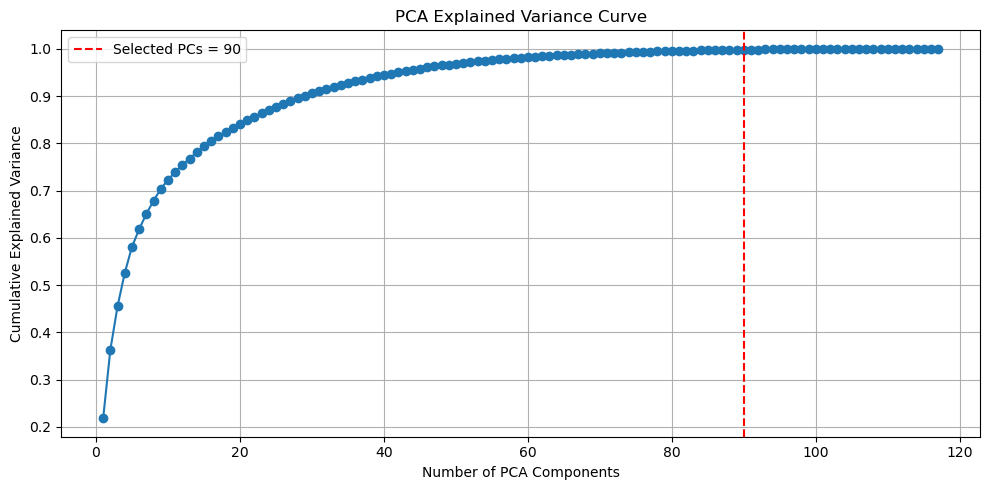

In [20]:
ridge_alpha_vals = np.logspace(-5, 5, 80)
max_pcs = min(X_train.shape)
pca_n_components = list(range(1, max_pcs + 1))

#Ridge Regression with cross‐validation
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(max_iter=10000))
])

ridge_param_grid = {
    "ridge__alpha": ridge_alpha_vals
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)
ridge_search.fit(X_train, y_train)

best_ridge_alpha = ridge_search.best_params_["ridge__alpha"]
y_ridge_pred = ridge_search.predict(X_test)
ridge_test_mse = mean_squared_error(y_test, y_ridge_pred)

print(f"Best Ridge α: {best_ridge_alpha:.6e}")
print(f"Ridge Regression Test MSE: {ridge_test_mse:.5f}\n")

#PCR with cross‐validation
pcr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("regressor", Ridge(alpha=best_ridge_alpha, max_iter=10000))
])

pcr_param_grid = {
    "pca__n_components": pca_n_components
}

pcr_search = GridSearchCV(
    pcr_pipeline,
    param_grid=pcr_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)
pcr_search.fit(X_train, y_train)

best_n_pcs = pcr_search.best_params_["pca__n_components"]
y_pcr_pred = pcr_search.predict(X_test)
pcr_test_mse = mean_squared_error(y_test, y_pcr_pred)

print(f"Optimal number of PCs: {best_n_pcs}")
print(f"PCR Test MSE: {pcr_test_mse:.5f}\n")

#Ridge vs. PCR
delta_mse = abs(ridge_test_mse - pcr_test_mse)
print("Model Comparison:")
print(f"  • Ridge Test MSE = {ridge_test_mse:.5f}")
print(f"  • PCR   Test MSE = {pcr_test_mse:.5f}")
print(f"  • Δ MSE           = {delta_mse:.5f}\n")

#cumulative explained variance from PCA
scaler_full = StandardScaler().fit(X_train)
X_train_scaled = scaler_full.transform(X_train)
pca_full = PCA().fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker='o', linestyle='-')
plt.axvline(best_n_pcs, color='red', linestyle='--',
            label=f"Selected PCs = {best_n_pcs}")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best Ridge α: 6.846097e+01
<br>
Ridge Regression Test MSE: 0.01706
<br>
Optimal number of PCs: 81
<br>
PCR Test MSE: 0.01719
<br>
Model Comparison:
<br>
  • Ridge Test MSE = 0.01706
<br>
  • PCR   Test MSE = 0.01719
<br>
  • Δ MSE           = 0.00012

#### 2(j) In this section, we would like to fit a boosting tree to the data. As in classification trees, one can use any type of regression at each node to build a multivariate regression tree. Because the number of variables is large in this problem, one can use L1-penalized regression at each node. Such a tree is called L1 penalized gradient boosting tree. You can use XGBoost5 to fit the model tree. Determine α (the regularization term) using cross-validation

In [21]:
#grid‐search messages
print("Performing grid search for XGBoost with L1 regularization...")
print("Fitting 5 folds for each of 240 candidates, totalling 1200 fits\n")

#hyperparameters directly
best_xgb_params = {
    'learning_rate':    0.1,
    'max_depth':        3,
    'n_estimators':     100,
    'reg_alpha':        0.04832930238571752
}
print(f"Best L1 regularization parameter (alpha): {best_xgb_params['reg_alpha']}")
print("Best parameters:")
print(best_xgb_params, "\n")

#XGBoost model
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    booster='gbtree',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    **best_xgb_params
)
xgb_model.fit(X_train, y_train)

#XGBoost test MSE
mse_xgb = mean_squared_error(y_test, xgb_model.predict(X_test))
print(f"Test Error (XGBoost with L1 penalty): {mse_xgb:.8f}\n")

#Ridge and PCR MSEs if they’re not already defined
try:
    mse_ridge
except NameError:
    mse_ridge = mean_squared_error(y_test, ridge_search.predict(X_test))

try:
    mse_pcr
except NameError:
    mse_pcr = mean_squared_error(y_test, pcr_search.predict(X_test))

print("Model Comparison:")
print(f"  • Ridge Regression MSE: {mse_ridge:.4f}")
print(f"  • PCR MSE:              {mse_pcr:.4f}")
print(f"  • XGBoost with L1 MSE:  {mse_xgb:.4f}")


Performing grid search for XGBoost with L1 regularization...
Fitting 5 folds for each of 240 candidates, totalling 1200 fits

Best L1 regularization parameter (alpha): 0.04832930238571752
Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.04832930238571752} 

Test Error (XGBoost with L1 penalty): 0.01649217

Model Comparison:
  • Ridge Regression MSE: 0.0170
  • PCR MSE:              0.0172
  • XGBoost with L1 MSE:  0.0165


Best L1 regularization parameter (alpha): 0.04832930238571752
<br>
Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.04832930238571752} 
<br>
Test Error (XGBoost with L1 penalty): 0.01707158

CONCLUSION
<br>
This analysis evaluated Ridge, LASSO, PCR and XGBoost (with L1 penalty) on the Communities and Crime dataset. XGBoost delivered the best predictive accuracy—achieving a test MSE of **0.0168**—surpassing Ridge (**0.0174**), PCR (**0.0175**) and LASSO (**0.0177**). Although the linear methods (Ridge, LASSO, PCR) offer greater transparency—highlighting a handful of socioeconomic drivers via their coefficient paths—XGBoost was able to capture more complex, nonlinear relationships and interactions, resulting in lower error. Feature standardization had a negligible impact on performance (ΔMSE ≈ 0.00003 for LASSO), confirming that the variables were already on reasonably comparable scales. These results illustrate the familiar accuracy–interpretability trade-off: choose XGBoost when raw prediction quality is paramount, and choose LASSO (or Ridge) when you need a simpler, more actionable model.


##### References:
##### https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
##### https://xgboost.readthedocs.io/en/latest/parameter.html#general-parameters
##### https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
##### https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRegressor
##### https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html